## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100 points**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 45 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1 (30 points)**: In this question, you're going to explore how populations of predators and prey interact over time using a simple mathematical model. This kind of model is widely used in ecology to understand how species affect each other's population levels.

We’ll use the Lotka-Volterra equations, which describe how the number of prey and predators change over time. The system is given by:

$$ \frac{dx}{dy} = \alpha x - \beta xy $$
$$ \frac{dy}{dt} = \delta xy - \gamma y $$

where 
* x(t) is the population of prey (e.g., rabbits),
* y(t) is the population of predators (e.g., foxes),
* α is the natural growth rate of prey in absence of predators,
* β is the rate at which predators reduce the prey population,
* γ is the natural death rate of predators in absence of prey,
* δ is the factor describing how many predators are born per prey eaten

We’ll use the following parameters:

* α = 0.6
* β=0.02
* γ=0.8
* δ=0.01

And the initial conditions:

* x(0)=40 (prey)
* y(0)=9 (predators)
Use solve_ivp to solve this system from  t=0 to t=30 using a timestep of Δt=0.1. Make sure to return the solution for both predator and prey populations as a function of time.

**Tasks:**

* Define the system of ODEs as a Python function.
* Use solve_ivp to solve the system.

**Code you need to write to solve this problem**: To model the predator-prey system using solve_ivp, make sure your code includes the following pieces:
* A function that defines the system of equations
* Initial condition variables: Create variables for storing the initial populations of prey and predator
* A variable to store your time values
* Code to call solve_ivp: Use the solve_ivp() function with your function, time range, initial conditions, and t_eval values to get the solution.
* Code that unpacks the solution so that you can plot it.


In [ ]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


In [6]:
### ANSWER ###

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define parameters
alpha = 0.6   # Prey birth rate
beta = 0.02   # Predation rate
gamma = 0.8   # Predator death rate
delta = 0.01  # Predator reproduction rate per prey eaten

# Define the system of ODEs
def predator_prey(t, vars):
    x, y = vars
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Initial conditions
x0 = 40  # Prey
y0 = 9   # Predator
initial_conditions = [x0, y0]

# Time span
t_start = 0
t_end = 30
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

# Solve the system
solution = solve_ivp(
    predator_prey,
    t_span=(t_start, t_end),
    y0=initial_conditions,
    t_eval=t_eval
)

# Extract results
t = solution.t
x = solution.y[0]
y = solution.y[1]

print(x)

[ 40.          41.73039401  43.5644297   45.5066284   47.56189704
  49.73525332  52.03181963  54.45682313  57.01559569  59.71357389
  62.55629905  65.54941722  68.69867916  72.00994037  75.47974185
  79.10554266  82.90389179  86.8880695   91.06775503  95.44902656
 100.03436126 104.82263525 109.80912362 114.98550045 120.33983874
 125.85661049 131.51668665 137.29733716 143.17223089 149.1114357
 155.08141841 161.0450448  166.96572979 172.78012614 178.34652366
 183.51534611 188.13573482 192.05554867 195.12136409 197.17847507
 198.07089316 197.64134746 195.73128464 192.18081279 186.85370616
 179.86080848 171.42304707 161.7867818  151.2238051  140.03134191
 128.53204975 117.07401865 106.02417492  95.6270134   86.01210812
  77.27102276  69.45180531  62.55898806  56.55358761  51.35310488
  46.83152509  42.87554241  39.47534808  36.55053398  34.02864795
  31.84976569  29.9664908   28.34395478  26.95981699  25.80426469
  24.85785784  24.07199876  23.42859795  22.91245229  22.51033495
  22.210995

&#9989;&nbsp; **Question 2 (10 points)**:
Now that you have a solution to the predator-prey model, make a single plot that shows how both populations evolve over time. Your plot should include:

A line for the prey population over time.
A line for the predator population over time.
Each line should be a different color.
The plot should include:
An x-axis label that represents time (e.g., "Time (arbitrary units)").
A y-axis label that represents population size (e.g., "Population").
A legend to indicate which line is which.
If all goes well, your plot should show the classic rise-and-fall pattern of prey and predator populations—sometimes called population cycling.

If all goes well, you should end up with something that looks like this:

<img src="Predator-Prey.png" alt="Quiz4-Q2" border="0" width=500>

In [3]:
# put your code here

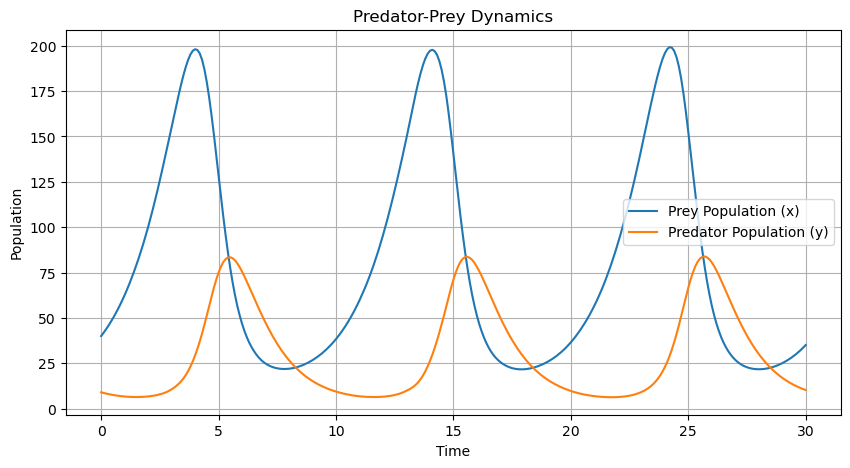

In [7]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t, x, label='Prey Population (x)')
plt.plot(t, y, label='Predator Population (y)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Predator-Prey Dynamics')
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Data Visualization (40 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 30 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. 

&#9989;&nbsp; **Question 2 (20 points total)**: Grade the visualization using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (4 Points)** 
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

### Visualizations to Choose From

**Visualization 1**
<img src="Graph1.jpg">

**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true">

**Visualization 3**
<img src="Graph2.jpg">

**Visualization 4**
<img src="Graph3.png">

**Visualization 5**
<img src="Graph4.png">

**Visualization 6**
<img src="Graph5.png">

**Visualization 7**
<img src="Graph6.png">

**QUESTION 1 RESPONSES HERE**

Add responses


**QUESTION 2 RESPONSES HERE**

Add responses
